Source: sc-best-practices book: Heumos, L., Schaar, A.C., Lance, C. et al. Best practices for single-cell analysis across modalities. Nat Rev Genet (2023). https://doi.org/10.1038/s41576-023-00586-w

# preprocessing steps
- doublet detection
- quality control
- normalization
- feature selection
- dimensionality reduction

# Preprocessing and visualization

## 6. Quality Control

### 6.2. Environment setup and data

In [1]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [2]:
# Load the Xenium dataset
# (own code)
import os
import spatialdata as sd

sdata = sd.read_zarr(os.path.join("..", "datasets", "xenium.zarr"))
adata = sdata.tables["table"]
adata

c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
version mismatch: detected: RasterFormatV02, requested: FormatV04
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _

AnnData object with n_obs × n_vars = 189598 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [3]:
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 189598 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

### 6.3. Filtering low quality cells

[W]e define cell quality control (QC) threshold. Cell QC is typically performed on the following three QC covariates:

- The number of counts per barcode (count depth)
- The number of genes per barcode
- The fraction of counts from mitochondrial genes per barcode


However, as datasets grow in size [...] it might be worth considering automatic thresholding via MAD (median absolute deviations). The MAD [...] describes a robust statistic of the variability of the metric. Similar to [Germain et al., 2020], we mark cells as outliers if they differ by 5 MADs which is a relatively permissive filtering strategy. We want to highlight that it might be reasonable to re-assess the filtering after annotation of cells.

In [4]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-" or "mt-")

#print(adata.var["mt"].sum(), "mitochondrial genes")

In [5]:
# calculate the QC covariates or metric
# it can also calculate the proportions of counts for specific gene populations
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=[20], log1p=True)
adata

AnnData object with n_obs × n_vars = 189598 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

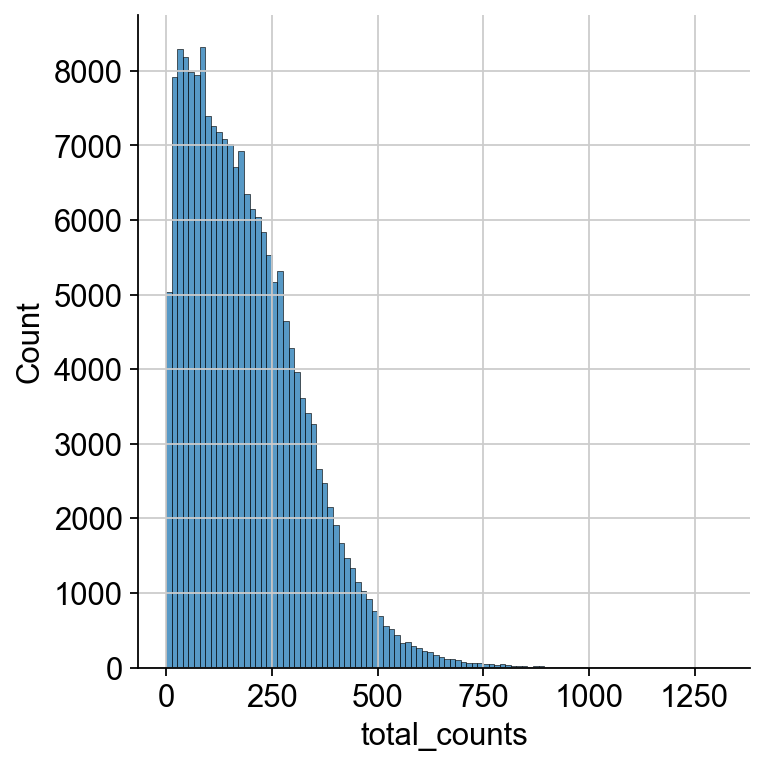

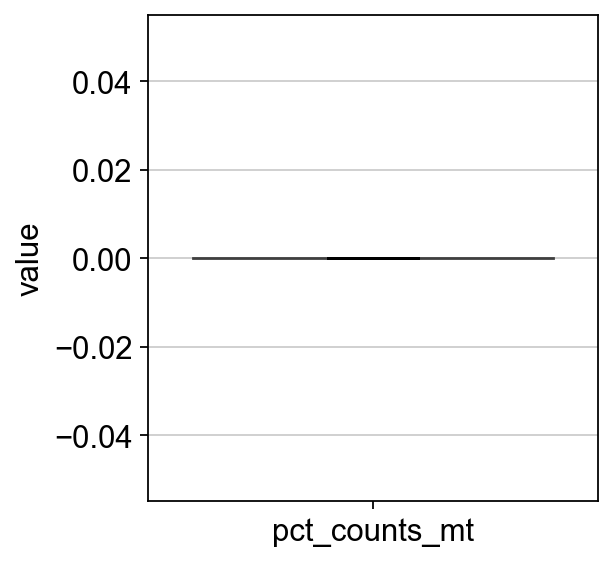

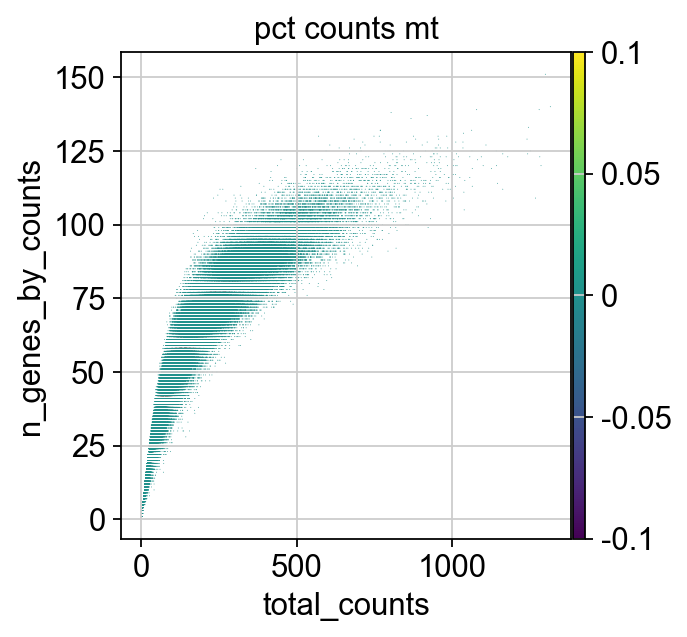

In [6]:
#  plot the three QC covariates n_genes_by_counts, total_counts and pct_counts_mt per sample

p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

[W]e will show QC with automatic thresholding and filtering based on MAD.

In [7]:
# First, we define a function that takes a metric, i.e. a column in .obs and the number of MADs (nmad) that is still permissive within the filtering strategy.
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (np.median(M) + nmads * median_abs_deviation(M) < M)
    return outlier

In [8]:
# We now apply this function to the log1p_total_counts, log1p_n_genes_by_counts and pct_counts_in_top_20_genes QC covariates each with a threshold of 5 MADs.
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    178682
True      10916
Name: count, dtype: int64

In [9]:
# pct_counts_Mt is filtered with 3 MADs. Additionally, cells with a percentage of mitochondrial counts exceeding 8 % are filtered out.
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    189598
Name: count, dtype: int64

In [10]:
# We now filter our AnnData object based on these two additional columns.
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 189598
Number of cells after filtering of low quality cells: 178682


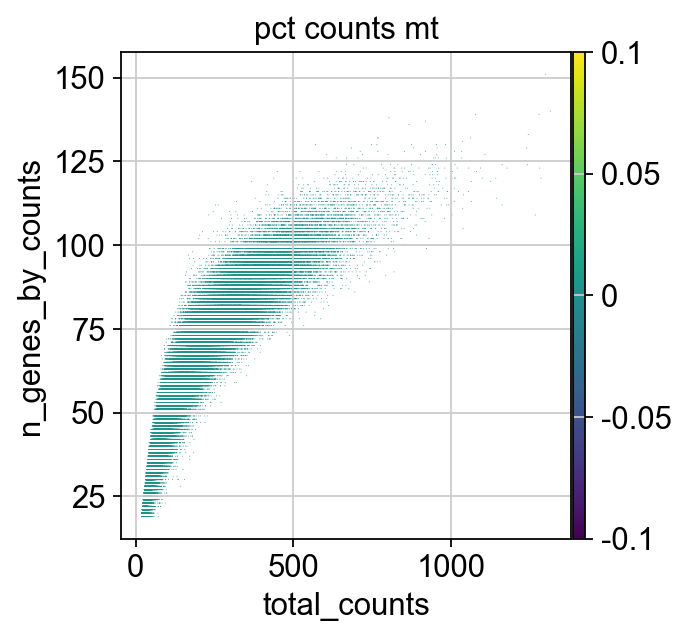

In [11]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### 6.4. Correction of ambient RNA

In [1]:
import logging

import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro

rcb.logger.setLevel(logging.ERROR)
#ro.pandas2ri.activate()
import rpy2
print(rpy2.__version)
anndata2ri.activate()

#%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\rpy2\rinterface\__init__.py:1185: UserWarning: Environment variable "PATH" redefined by R and overriding existing variable. Current: "c:\Users\rebec\miniforge3\envs\mapra_me;C:\Users\rebec\miniforge3\envs\mapra_me;C:\Users\rebec\miniforge3\envs\mapra_me\Library\mingw-w64\bin;C:\Users\rebec\miniforge3\envs\mapra_me\Library\usr\bin;C:\Users\rebec\miniforge3\envs\mapra_me\Library\bin;C:\Users\rebec\miniforge3\envs\mapra_me\Scripts;C:\Users\rebec\miniforge3\envs\mapra_me\bin;C:\Users\rebec\miniforge3\condabin;C:\Program Files\Eclipse Adoptium\jdk-11.0.13.8-hotspot\bin;C:\Program Files\Common Files\Oracle\Java\javapath;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0;C:\WINDOWS\System32\OpenSSH;C:\Program Files\Git\cmd;C:\Program Files\Java\jdk-17.0.2\bin;C:\Program Fil

TypeError: attribute name must be string, not 'NoneType'

In [17]:
adata_pp = adata.copy()
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)

sc.pp.pca(adata_pp)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="soupx_groups")

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]


del adata_pp

cells = adata.obs_names
genes = adata.var_names
data = adata.X.T



import winsound
winsound.MessageBeep()

C:\Users\rebec\AppData\Local\Temp\ipykernel_26068\3239632702.py:2: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata_pp)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\scanpy\preprocessing\_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\rebec\AppData\Local\Temp\ipykernel_26068\3239632702.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pp, key_added="soupx_groups")



### 6.6 Key Takeaways

- Filtering of poor-quality cells should be based on median absolute deviations with lenient cutoffs to avoid bias against smaller subpopulations.

- Feature-based filtering does not show benefits for downstream tasks.

- Doublets can be efficiently detected with tools like scDblFinder.

- Doublet detection methods should not be run on aggregated scRNA-seq data representing multiple batches.
